# First Load the .graphml files

In [ ]:
from pathlib import Path
import networkx as nx

folder_path = Path(".\\asnr datasets")
print(folder_path.exists())


asnr_graphs = {}

for file_path in folder_path.glob('*.graphml'):
    graph = nx.read_graphml(file_path)

    key_name = file_path.stem + ".graphml"

    asnr_graphs[key_name] = graph


True


In [ ]:
print(asnr_graphs.keys())

dict_keys(['Network_0', 'Network_1', 'Network_10', 'Network_100', 'Network_1000', 'Network_1001', 'Network_1002', 'Network_1003', 'Network_1004', 'Network_1005', 'Network_1006', 'Network_1007', 'Network_1008', 'Network_1009', 'Network_101', 'Network_1010', 'Network_1011', 'Network_1012', 'Network_1013', 'Network_1014', 'Network_1015', 'Network_1016', 'Network_1017', 'Network_1018', 'Network_1019', 'Network_102', 'Network_1020', 'Network_1021', 'Network_1022', 'Network_1023', 'Network_1024', 'Network_1025', 'Network_1026', 'Network_1027', 'Network_1028', 'Network_1029', 'Network_103', 'Network_1030', 'Network_1031', 'Network_1032', 'Network_1033', 'Network_1034', 'Network_1035', 'Network_1036', 'Network_1037', 'Network_1038', 'Network_1039', 'Network_104', 'Network_1040', 'Network_1041', 'Network_1042', 'Network_1043', 'Network_1044', 'Network_1045', 'Network_1046', 'Network_1047', 'Network_1048', 'Network_1049', 'Network_105', 'Network_1050', 'Network_1051', 'Network_1052', 'Network_10

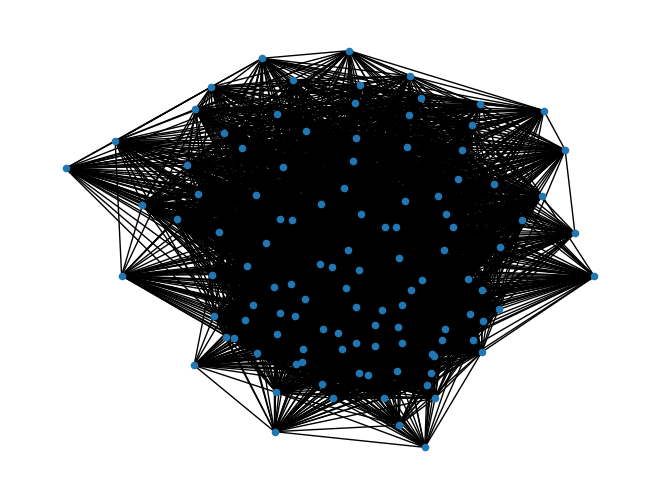

In [ ]:
nx.draw(
    asnr_graphs["Network_9.graphml"],
    node_size=20
)

In [ ]:
import pandas as pd

graph_info_file = ".\\asnr datasets\\Network_summary_masterfile.csv"

info_frame = pd.read_csv(graph_info_file)

print(info_frame.iloc[0])

Network_ID                                                      Network_0.graphml
Network_Identifiers                                         ant mersch col1 day01
class                                                                     Insecta
genus                                                                  Camponotus
species                                                                    fellah
interaction_type                                                 physical_contact
definition_of_interaction       A pair of ants was considered to interact when...
edge_wt_type                                                            frequency
geographical_location               University of Lausanne, Laussane, Switzerland
population_type                                                           captive
data_record_technique                                                       video
time_span                                                                    1day
resolution      

# Set up new DataFrame

In [ ]:
import torch
from torch_geometric.data import Data

dataset = []

for key, graph in asnr_graphs.items():
    # Get label from DataFrame
    label = info_frame.loc[info_frame['Network_ID'] == key, 'class'].values[0]
    
    # Node features: here we use degree as a simple feature
    x = torch.tensor([[d] for _, d in graph.degree()], dtype=torch.float)
    
    # Edges
    edge_index = torch.tensor(list(graph.edges()), dtype=torch.long).t().contiguous()
    
    # Graph label
    y = torch.tensor([label], dtype=torch.long)
    
    data = Data(x=x, edge_index=edge_index, y=y)
    dataset.append(data)

IndexError: index 0 is out of bounds for axis 0 with size 0